In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
warnings.filterwarnings('ignore')

print("Libraries loaded!")

Libraries loaded!


In [ ]:
from google.colab import files
upload = files.upload()

Saving silver_daily_ohlcv_2000_2025.csv to silver_daily_ohlcv_2000_2025.csv


In [ ]:
df = pd.read_csv('silver_daily_ohlcv_2000_2025.csv')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date').reset_index(drop=True)
print(f"Shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(df.head(3))

Shape: (6783, 13)
Date range: 2000-01-03 00:00:00 to 2025-12-31 00:00:00
        Date    Open    High     Low   Close  Adj_Close  Volume    VWAP  \
0 2000-01-03  5.1962  5.1962  5.1884  5.1910     5.1910   36286  5.1919   
1 2000-01-04  5.1084  5.1084  5.0848  5.0980     5.0980   35819  5.0971   
2 2000-01-05  5.1388  5.1464  5.1388  5.1412     5.1412   38844  5.1421   

   Returns_Pct  Log_Returns  Dollar_Change  Intraday_Range  Intraday_Range_Pct  
0      -0.1729    -0.001731        -0.0090          0.0078              0.1511  
1      -1.7916    -0.018079        -0.0930          0.0236              0.4649  
2       0.8480     0.008444         0.0432          0.0076              0.1472  


In [ ]:
# Train/test split - no leakage verification
train = df[df['Date'] < '2020-01-01'].copy()
test = df[df['Date'] >= '2020-01-01'].copy()

print(f"Train size: {len(train)} rows")
print(f"Test size: {len(test)} rows")
print(f"Train range: {train['Date'].min().date()} to {train['Date'].max().date()}")
print(f"Test range: {test['Date'].min().date()} to {test['Date'].max().date()}")
print(f"Overlap check: {len(train[train['Date'].isin(test['Date'])])} overlapping dates")
print("\nNo data leakage!" if len(train[train['Date'].isin(test['Date'])]) == 0 else "WARNING: Leakage detected!")

Train size: 5217 rows
Test size: 1566 rows
Train range: 2000-01-03 to 2019-12-31
Test range: 2020-01-01 to 2025-12-31
Overlap check: 0 overlapping dates

No data leakage!


In [ ]:
# Re-run ARIMA on clean test set
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

model = ARIMA(train['Close'], order=(5,1,0))
fitted = model.fit()
forecast = fitted.forecast(steps=len(test))
forecast = forecast.values

mae = mean_absolute_error(test['Close'], forecast)
rmse = np.sqrt(mean_squared_error(test['Close'], forecast))
mape = np.mean(np.abs((test['Close'].values - forecast) / test['Close'].values)) * 100

print("=== ARIMA Model Validation ===")
print(f"MAE:  ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"Test period: {test['Date'].min().date()} to {test['Date'].max().date()}")
print(f"Test rows: {len(test)}")

=== ARIMA Model Validation ===
MAE:  $7.79
RMSE: $8.95
MAPE: 28.17%
Test period: 2020-01-01 to 2025-12-31
Test rows: 1566


In [ ]:
# SMA baseline model validation
sma_value = train['Close'].rolling(20).mean().iloc[-1]
sma_forecast = np.full(len(test), sma_value)

mae_sma = mean_absolute_error(test['Close'], sma_forecast)
rmse_sma = np.sqrt(mean_squared_error(test['Close'], sma_forecast))
mape_sma = np.mean(np.abs((test['Close'].values - sma_forecast) / test['Close'].values)) * 100

print("=== SMA Baseline Validation ===")
print(f"MAE:  ${mae_sma:.2f}")
print(f"RMSE: ${rmse_sma:.2f}")
print(f"MAPE: {mape_sma:.2f}%")
print(f"SMA value used: ${sma_value:.2f}")

=== SMA Baseline Validation ===
MAE:  $8.00
RMSE: $9.15
MAPE: 28.93%
SMA value used: $18.39


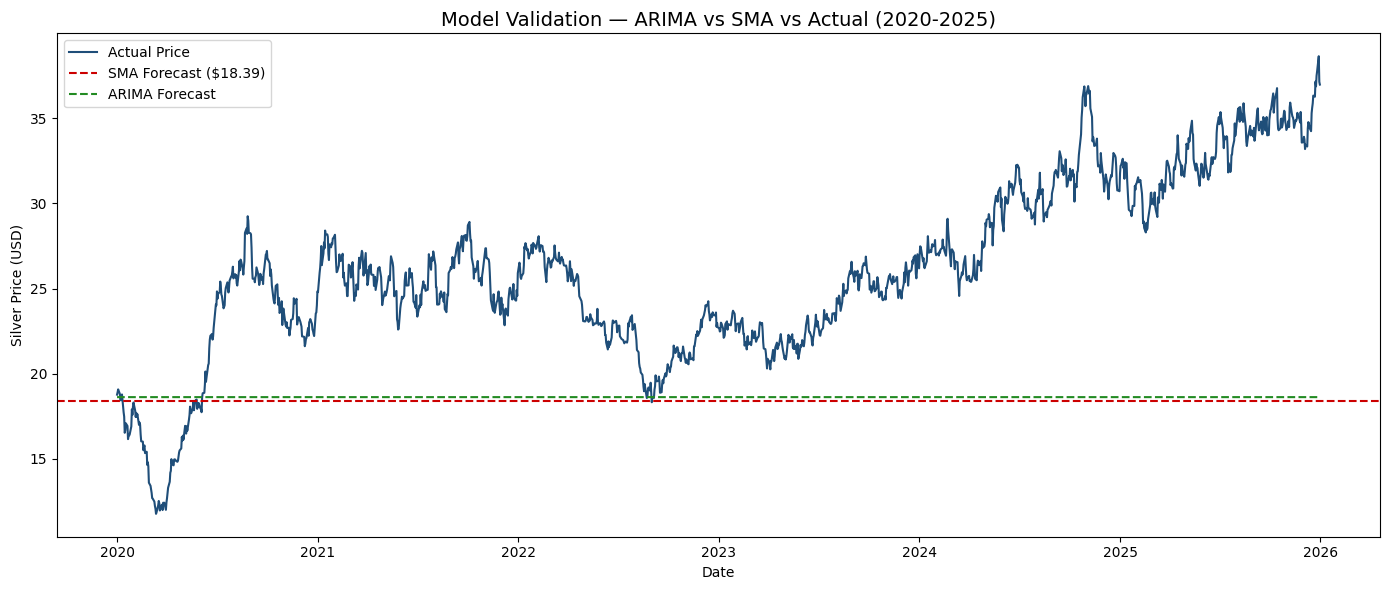

Validation chart saved!


In [ ]:
plt.figure(figsize=(14,6))
plt.plot(test['Date'], test['Close'], label='Actual Price', color='#1F4E79', linewidth=1.5)
plt.axhline(y=sma_value, color='#CC0000', linestyle='--', linewidth=1.5, label=f'SMA Forecast (${sma_value:.2f})')
plt.plot(test['Date'], forecast, color='#228B22', linestyle='--', linewidth=1.5, label='ARIMA Forecast')
plt.title('Model Validation — ARIMA vs SMA vs Actual (2020-2025)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Silver Price (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('model_validation.png', dpi=150)
plt.show()
print("Validation chart saved!")


In [ ]:
import pkg_resources

packages = ['pandas', 'numpy', 'matplotlib', 'statsmodels', 'scikit-learn']
with open('requirements.txt', 'w') as f:
    for pkg in packages:
        version = pkg_resources.get_distribution(pkg).version
        f.write(f"{pkg}=={version}\n")

# Print contents
with open('requirements.txt', 'r') as f:
    print(f.read())

pandas==2.2.2
numpy==2.0.2
matplotlib==3.10.0
statsmodels==0.14.6
scikit-learn==1.6.1



In [ ]:
def test_data_loading():
    assert len(df) > 0, "DataFrame should not be empty"
    assert 'Close' in df.columns, "Close column missing"
    assert 'Date' in df.columns, "Date column missing"
    print("✅ test_data_loading passed")

def test_no_data_leakage():
    overlap = len(train[train['Date'].isin(test['Date'])])
    assert overlap == 0, f"Data leakage detected: {overlap} overlapping dates"
    print("✅ test_no_data_leakage passed")

def test_train_test_split():
    assert len(train) > 0, "Train set empty"
    assert len(test) > 0, "Test set empty"
    assert train['Date'].max() < test['Date'].min(), "Train/test dates overlap"
    print("✅ test_train_test_split passed")

def test_arima_metrics():
    assert mae < 15, f"MAE too high: {mae}"
    assert mape < 50, f"MAPE too high: {mape}"
    print("✅ test_arima_metrics passed")

# Run all tests
test_data_loading()
test_no_data_leakage()
test_train_test_split()
test_arima_metrics()
print("\n🎉 All tests passed!")

✅ test_data_loading passed
✅ test_no_data_leakage passed
✅ test_train_test_split passed
✅ test_arima_metrics passed

🎉 All tests passed!


In [ ]:
def load_silver_data(filepath: str) -> pd.DataFrame:
    """
    Load and preprocess silver OHLCV data from CSV.

    Args:
        filepath: Path to the CSV file

    Returns:
        Cleaned and sorted DataFrame with datetime index
    """
    df = pd.read_csv(filepath)
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
    df = df.sort_values('Date').reset_index(drop=True)
    return df


def split_train_test(df: pd.DataFrame, cutoff_date: str) -> tuple:
    """
    Split DataFrame into train and test sets with no leakage.

    Args:
        df: Input DataFrame with Date column
        cutoff_date: Split date in 'YYYY-MM-DD' format

    Returns:
        Tuple of (train_df, test_df)
    """
    train = df[df['Date'] < cutoff_date].copy()
    test = df[df['Date'] >= cutoff_date].copy()
    return train, test


def calculate_metrics(actual: np.ndarray, predicted: np.ndarray) -> dict:
    """
    Calculate MAE, RMSE and MAPE for model evaluation.

    Args:
        actual: Array of actual values
        predicted: Array of predicted values

    Returns:
        Dictionary with mae, rmse, mape keys
    """
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return {'mae': round(mae, 2), 'rmse': round(rmse, 2), 'mape': round(mape, 2)}


print("✅ Clean functions defined with docstrings and type hints!")


✅ Clean functions defined with docstrings and type hints!
